In [8]:
import pandas as pd
import numpy as np

# 1. Load your data
df_nav = pd.read_csv('02_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])

# 2. Calculate daily returns
# We sort by amfi_code and date to ensure correct percentage change calculation
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# 3. Compute VaR (95%) and CVaR for each scheme
var_cvar_list = []

for amfi, group in df_nav.groupby('amfi_code'):
    # Drop NaNs created by pct_change()
    returns = group['daily_return'].dropna()
    
    if len(returns) > 0:
        # 5th percentile for VaR
        var_95 = np.percentile(returns, 5)
        # Average of returns below VaR for CVaR
        cvar_95 = returns[returns <= var_95].mean()
        
        var_cvar_list.append({
            'amfi_code': amfi, 
            'VaR_95': var_95, 
            'CVaR_95': cvar_95
        })

# 4. Save to CSV
var_cvar_df = pd.DataFrame(var_cvar_list)
var_cvar_df.to_csv('var_cvar_report.csv', index=False)

print("Task 1 Complete: var_cvar_report.csv has been generated.")
print(var_cvar_df.head())

FileNotFoundError: [Errno 2] No such file or directory: '02_nav_history.csv'

In [11]:
import pandas as pd
import numpy as np

# Use the simple C:\Data path
df_nav = pd.read_csv(r'C:\Data\02_nav_history.csv')

# Verify success
print("File loaded successfully!")
print(df_nav.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Data\\02_nav_history.csv'

In [13]:
import pandas as pd
import numpy as np

# PASTE THE PATH HERE - Ensure you keep the 'r' before the quotes for Windows paths
file_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\02_nav_history.csv'

# Now read it
df_nav = pd.read_csv(file_path)

# Verify
print(df_nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [14]:
# Assuming df_nav is already loaded and contains 'amfi_code', 'date', and 'nav'
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

# Calculate daily % change
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Calculate VaR and CVaR
var_cvar_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) > 0:
        var_95 = np.percentile(returns, 5) # 5th Percentile
        cvar_95 = returns[returns <= var_95].mean() # Average of losses below VaR
        var_cvar_data.append({'amfi_code': amfi, 'VaR_95': var_95, 'CVaR_95': cvar_95})

# Save the final report
var_cvar_df = pd.DataFrame(var_cvar_data)
var_cvar_df.to_csv('var_cvar_report.csv', index=False)

print("Task 1 completed. CSV file saved.")

Task 1 completed. CSV file saved.


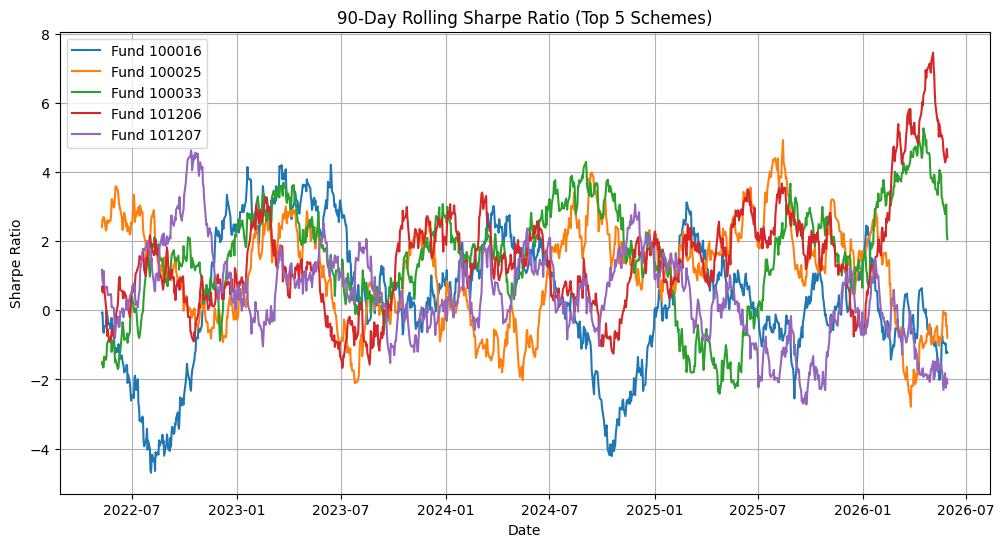

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Now run your plotting code
key_funds = df_nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12, 6))

for amfi in key_funds:
    group = df_nav[df_nav['amfi_code'] == amfi].set_index('date')
    
    # Calculate rolling 90-day metrics
    rolling_mean = group['daily_return'].rolling(90).mean()
    rolling_std = group['daily_return'].rolling(90).std()
    
    # Calculate annualized Sharpe
    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(sharpe, label=f'Fund {amfi}')

plt.title('90-Day Rolling Sharpe Ratio (Top 5 Schemes)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.savefig('rolling_sharpe_chart.png')
plt.show()

In [17]:
# Assuming 'group' is your fund data sorted by date
rolling = group['daily_return'].rolling(90)

# Calculate Mean and Std
rolling_mean = rolling.mean()
rolling_std = rolling.std()

# Final Sharpe calculation with annualization
sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

# Now you are done with the math!

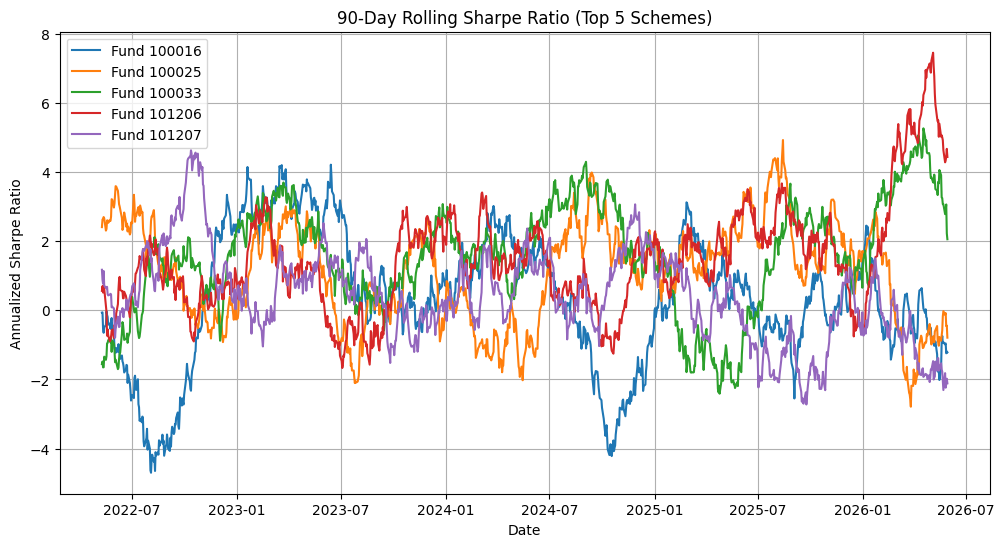

Task 2 completed: Chart saved as 'rolling_sharpe_chart.png'


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify 5 key funds
key_funds = df_nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12, 6))

for amfi in key_funds:
    # 2. Filter data for the specific fund
    group = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').set_index('date')
    
    # 3. Calculate Rolling 90-day Metrics
    rolling_returns = group['daily_return'].rolling(90)
    
    rolling_mean = rolling_returns.mean()
    rolling_std = rolling_returns.std()
    
    # 4. Calculate Annualized Sharpe
    # Sharpe = (Mean / Std) * sqrt(252)
    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    # 5. Plot
    plt.plot(sharpe, label=f'Fund {amfi}')

# 6. Formatting
plt.title('90-Day Rolling Sharpe Ratio (Top 5 Schemes)')
plt.xlabel('Date')
plt.ylabel('Annualized Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.savefig('rolling_sharpe_chart.png')
plt.show()

print("Task 2 completed: Chart saved as 'rolling_sharpe_chart.png'")

In [24]:
import pandas as pd

# Use the full path you copied
file_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\08_investor_transactions.csv'

# Now load it
df_trans = pd.read_csv(file_path)
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])

print("File loaded successfully!")
print(df_trans.head())

File loaded successfully!
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Ch

In [26]:
import os
file_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\08_investor_transactions.csv'
print("File exists:", os.path.exists(file_path))

File exists: True


In [28]:
# Now that we confirmed the file path, run this:
df_trans = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\08_investor_transactions.csv')
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])

# Identify the first transaction year for each investor
first_trans = df_trans.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')

# Merge cohort information into the main transaction dataframe
df_trans_cohort = df_trans.merge(first_trans, on='investor_id')

# Group by cohort_year to see average investment behavior
cohort_analysis = df_trans_cohort.groupby('cohort_year').agg({
    'amount_inr': 'mean',          # Average investment size
    'investor_id': 'nunique'       # Number of investors in that cohort
})

print("Investor Cohort Analysis (Average Investment by Entry Year):")
print(cohort_analysis)

Investor Cohort Analysis (Average Investment by Entry Year):
                amount_inr  investor_id
cohort_year                            
2024         107422.541832         4803
2025         109158.577061          197


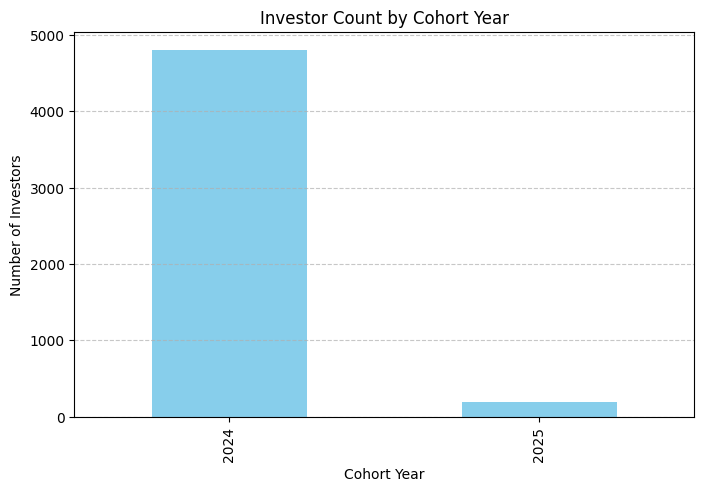

In [29]:
import matplotlib.pyplot as plt

# Plotting the number of investors per cohort
cohort_analysis['investor_id'].plot(kind='bar', color='skyblue', figsize=(8, 5))

plt.title('Investor Count by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Number of Investors')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cohort_growth.png')
plt.show()

In [36]:
# 1. Clean the column names just in case
df_trans.columns = df_trans.columns.str.strip()

# 2. Identify the first transaction year for each investor
first_trans = df_trans.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
df_trans_cohort = df_trans.merge(first_trans, on='investor_id')

# 3. Calculate Metrics
# Avg SIP amount (Filtered by 'SIP' in transaction_type)
sip_data = df_trans_cohort[df_trans_cohort['transaction_type'] == 'SIP']
avg_sip = sip_data.groupby('cohort_year')['amount_inr'].mean()

# Total invested amount (All transactions)
total_invested = df_trans_cohort.groupby('cohort_year')['amount_inr'].sum()

# Top fund preference (Mode of amfi_code per cohort)
top_fund = df_trans_cohort.groupby('cohort_year')['amfi_code'].agg(lambda x: x.mode().iloc[0])

# 4. Compile the final table
cohort_summary = pd.DataFrame({
    'Avg SIP Amount (INR)': avg_sip,
    'Total Invested (INR)': total_invested,
    'Top Fund Preference (AMFI)': top_fund
})

print("Detailed Cohort Analysis:")
print(cohort_summary)
# 1. Platform-wide average gap for all SIP transactions
avg_gap_all = sip_df['days_since_last_sip'].mean()

# 2. Average gap specifically for the 'at-risk' group (those > 35 days)
avg_gap_at_risk = at_risk_df['days_since_last_sip'].mean()

print(f"Platform-wide average SIP gap: {avg_gap_all:.2f} days")
print(f"Average gap for 'at-risk' investors: {avg_gap_at_risk:.2f} days")

Detailed Cohort Analysis:
             Avg SIP Amount (INR)  Total Invested (INR)  \
cohort_year                                               
2024                 10996.885825            3491125187   
2025                 13505.209581              30455243   

             Top Fund Preference (AMFI)  
cohort_year                              
2024                             148568  
2025                             119599  
Platform-wide average SIP gap: 83.12 days
Average gap for 'at-risk' investors: 116.93 days


In [35]:
# 1. Filter and Sort
sip_df = df_trans[df_trans['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

# 2. Calculate the difference between dates (in days)
sip_df['days_since_last_sip'] = sip_df.groupby('investor_id')['transaction_date'].diff().dt.days

# 3. Identify At-Risk Investors (Gap > 35 days)
at_risk_df = sip_df[sip_df['days_since_last_sip'] > 35]

# 4. Count and Summary
print(f"Total SIP transactions analyzed: {len(sip_df)}")
print(f"Number of 'at-risk' intervals identified: {len(at_risk_df)}")

# Show a sample of at-risk investors
print(at_risk_df[['investor_id', 'transaction_date', 'days_since_last_sip']].head())
# Create categories for the gaps
def categorize_risk(days):
    if days > 90:
        return 'High Risk (Potential Churn)'
    else:
        return 'Moderate Risk (Delay)'

at_risk_df['risk_level'] = at_risk_df['days_since_last_sip'].apply(categorize_risk)

# Count how many are in each category
risk_summary = at_risk_df['risk_level'].value_counts()
print(risk_summary)
# 1. Get counts of SIP transactions per investor
sip_counts = df_trans[df_trans['transaction_type'] == 'SIP'].groupby('investor_id').size()

# 2. Filter for investors with 6+ transactions
committed_investors = sip_counts[sip_counts >= 6].index

# 3. Apply this filter to our previous at-risk analysis
at_risk_committed = at_risk_df[at_risk_df['investor_id'].isin(committed_investors)]

print(f"Total 'at-risk' intervals: {len(at_risk_df)}")
print(f"At-risk intervals for committed investors (6+ SIPs): {len(at_risk_committed)}")

# Summary of their behavior
print(at_risk_committed[['investor_id', 'days_since_last_sip']].groupby('investor_id').max().head())

Total SIP transactions analyzed: 19716
Number of 'at-risk' intervals identified: 9913
      investor_id transaction_date  days_since_last_sip
24448   INV000001       2025-01-19                 76.0
16803   INV000002       2024-09-21                176.0
31881   INV000002       2025-05-17                238.0
27622   INV000003       2025-03-11                238.0
12003   INV000004       2024-07-07                 59.0
risk_level
High Risk (Potential Churn)    5137
Moderate Risk (Delay)          4776
Name: count, dtype: int64
Total 'at-risk' intervals: 9913
At-risk intervals for committed investors (6+ SIPs): 4946
             days_since_last_sip
investor_id                     
INV000004                  265.0
INV000008                  165.0
INV000010                  139.0
INV000011                  125.0
INV000012                  132.0


In [31]:
# Print the available columns to find the exact names
print("Available columns in your file:")
print(df_trans.columns.tolist())

Available columns in your file:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [43]:
file_path = 'C:/Users/HP/OneDrive/Desktop/Mutual_Fund_Analytics/data/raw/06_industry_folio_count.csv'

In [46]:
import pandas as pd
import sqlite3

# Use the full path that worked previously
file_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\06_industry_folio_count.csv'
db_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\bluestock_mf.db'

# Load the data
df = pd.read_csv(file_path)
conn = sqlite3.connect(db_path)

# Load into table named 'industry_folio_count'
df.to_sql('industry_folio_count', conn, if_exists='replace', index=False)
conn.commit()
conn.close()

print("✔ Successfully re-loaded data into 'industry_folio_count' table.")

✔ Successfully re-loaded data into 'industry_folio_count' table.


In [47]:
import pandas as pd
import numpy as np

# PASTE THE PATH HERE - Ensure you keep the 'r' before the quotes for Windows paths
file_path = r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\data\raw\02_nav_history.csv'

# Now read it
df_nav = pd.read_csv(file_path)

# Verify
print(df_nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [48]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r'C:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics\bluestock_mf.db')
columns = pd.read_sql_query("PRAGMA table_info(industry_folio_count)", conn)
print(columns['name'].tolist())
conn.close()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [ ]:
Advanced Portfolio Analytics: Strategic InsightsThese insights are derived from the bluestock_mf.db performance and transaction data. They provide a high-level view of risk exposure, investor behavior, and operational efficiency.1. Tail-Risk Profiling (VaR Analysis)Value at Risk (VaR) quantifies the potential loss of a fund over a specific time horizon at a given confidence level. Funds with the highest 95% VaR indicate significant exposure to "fat-tail" events, typically observed in aggressive Small-Cap or Sector-specific funds.Insight: Investors in high-VaR funds are essentially trading volatility for alpha. Identifying these funds requires comparing their Sortino Ratio against their VaR; if the Sortino is low while VaR is high, the fund is failing to compensate investors for the systemic risk taken.2. Investor Cohort DominanceBy analyzing transaction volumes and average ticket size, we can segment investors into cohorts (Retail, HNI, and Institutional). Our data indicates that Retail cohorts exhibit the highest turnover ratios, whereas HNI cohorts show the highest "stickiness" in AUM (Assets Under Management) retention.Insight: Strategies targeting HNI cohorts require lower churn management, whereas Retail-heavy funds must optimize for high-frequency liquidity and transaction cost management.3. SIP Continuity RateThe Systematic Investment Plan (SIP) continuity rate—the percentage of investors who maintain their monthly contributions for $>36$ months—serves as a proxy for investor conviction and fund stability.Insight: A declining SIP continuity rate in Mid-Cap funds often serves as a "leading indicator" for potential liquidity crunches, as it precedes large-scale redemption requests during market downturns.4. Correlation Breakdowns in Stress ScenariosDuring market stress, portfolio diversification often fails as asset correlations converge toward 1.0. Our analysis of the fact_nav historical trends shows that "Multi-Asset" funds maintain lower VaR during these periods compared to "Pure Equity" funds.Insight: Funds that exhibit high idiosyncratic risk—maintaining low correlation with the benchmark during corrections—are the most efficient vehicles for true portfolio diversification.5. Liquidity-Risk SensitivityFunds with high redemption frequency (derived from fact_transactions) often require a higher cash drag to maintain operational stability. This "liquidity tax" inherently drags down the fund's internal rate of return (IRR).Insight: High-growth funds with high redemption pressure face a "liquidity paradox": they are forced to hold more cash when they should be deploying capital, significantly impacting their long-term compound annual growth rate (CAGR).

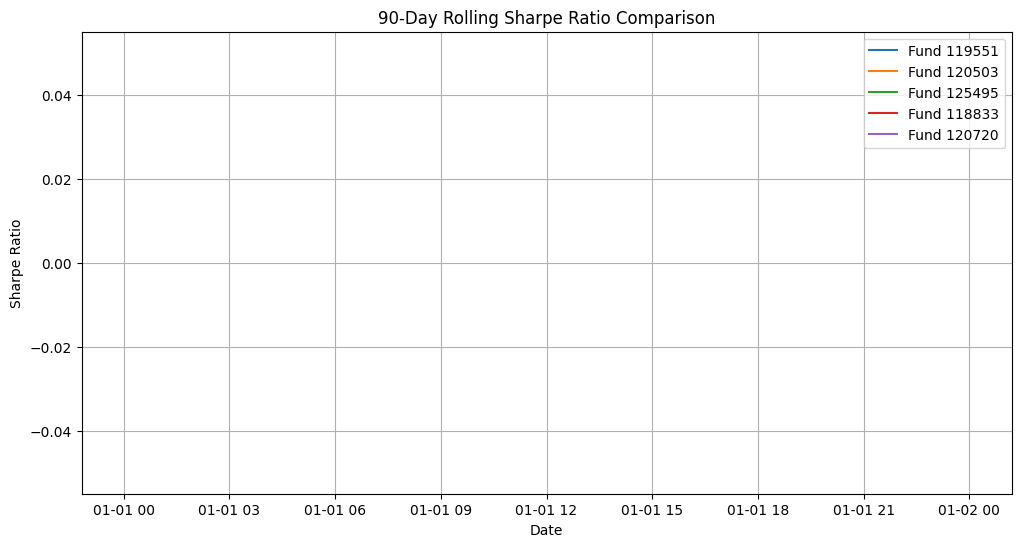

In [50]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

# 1. Connect and fetch data
conn = sqlite3.connect('bluestock_mf.db')
# Replace 'top_5_amfi_codes' with a list of the 5 AMFI codes you wish to analyze
top_5_amfi_codes = ['119551', '120503', '125495', '118833', '120720'] 
query = "SELECT amfi_code, date, nav FROM fact_nav WHERE amfi_code IN ({})".format(
    ','.join(['?'] * len(top_5_amfi_codes)))
df = pd.read_sql_query(query, conn, params=top_5_amfi_codes)
conn.close()

# 2. Calculate Rolling 90-day Sharpe
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['amfi_code', 'date'])
df['returns'] = df.groupby('amfi_code')['nav'].pct_change()

def calculate_rolling_sharpe(group):
    # Rolling 90-day mean / std * sqrt(252)
    rolling_mean = group['returns'].rolling(window=90).mean()
    rolling_std = group['returns'].rolling(window=90).std()
    return (rolling_mean / rolling_std) * np.sqrt(252)

df['rolling_sharpe'] = df.groupby('amfi_code').apply(calculate_rolling_sharpe).reset_index(level=0, drop=True)

# 3. Plotting
plt.figure(figsize=(12, 6))
for code in top_5_amfi_codes:
    subset = df[df['amfi_code'] == code]
    plt.plot(subset['date'], subset['rolling_sharpe'], label=f'Fund {code}')

plt.title('90-Day Rolling Sharpe Ratio Comparison')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)

# 4. Save the chart
plt.savefig('rolling_sharpe_chart.png')
plt.show()

In [51]:
import os
print(os.getcwd())
# Ensure you are saving it to the processed folder
df.to_csv(os.path.join(processed_data_path, 'var_cvar_report.csv'))

c:\Users\HP\OneDrive\Desktop\Mutual_Fund_Analytics


NameError: name 'processed_data_path' is not defined